In [6]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

df = pd.read_csv("instagram_usage_lifestyle.csv")

In [4]:
print(df.columns)

Index(['user_id', 'app_name', 'age', 'gender', 'country', 'urban_rural',
       'income_level', 'employment_status', 'education_level',
       'relationship_status', 'has_children', 'exercise_hours_per_week',
       'sleep_hours_per_night', 'diet_quality', 'smoking', 'alcohol_frequency',
       'perceived_stress_score', 'self_reported_happiness', 'body_mass_index',
       'blood_pressure_systolic', 'blood_pressure_diastolic',
       'daily_steps_count', 'weekly_work_hours', 'hobbies_count',
       'social_events_per_month', 'books_read_per_year',
       'volunteer_hours_per_month', 'travel_frequency_per_year',
       'daily_active_minutes_instagram', 'sessions_per_day',
       'posts_created_per_week', 'reels_watched_per_day',
       'stories_viewed_per_day', 'likes_given_per_day',
       'comments_written_per_day', 'dms_sent_per_week',
       'dms_received_per_week', 'ads_viewed_per_day', 'ads_clicked_per_day',
       'time_on_feed_per_day', 'time_on_explore_per_day',
       'time_on_

In [24]:
corrs = (
    df.corr(numeric_only=True)["daily_active_minutes_instagram"]
    .sort_values(ascending=False)
)

print(corrs.head(15))
print()
print(corrs.tail(15))

daily_active_minutes_instagram    1.000000
likes_given_per_day               0.980951
time_on_feed_per_day              0.974875
stories_viewed_per_day            0.955279
comments_written_per_day          0.942986
time_on_reels_per_day             0.934326
dms_received_per_week             0.922335
dms_sent_per_week                 0.898950
time_on_messages_per_day          0.897741
ads_viewed_per_day                0.891905
reels_watched_per_day             0.874479
time_on_explore_per_day           0.867795
perceived_stress_score            0.834515
sessions_per_day                  0.748179
ads_clicked_per_day               0.710315
Name: daily_active_minutes_instagram, dtype: float64

blood_pressure_diastolic      0.000176
exercise_hours_per_week       0.000040
travel_frequency_per_year     0.000008
body_mass_index              -0.000035
linked_accounts_count        -0.000278
notification_response_rate   -0.000346
account_creation_year        -0.000645
daily_steps_count           

------------------------------------------------------

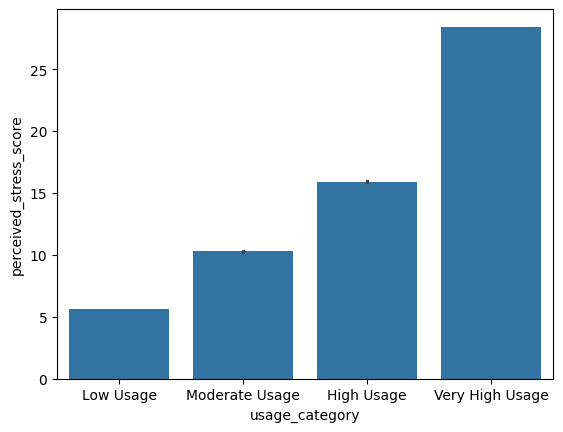

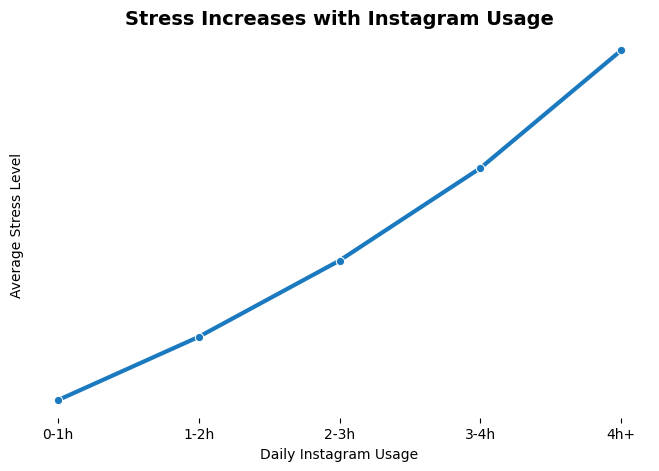

In [ ]:
#grafica de barras ----------------------------------

# Crear categorías de uso de Instagram

df["usage_category"] = pd.cut(
    df["daily_active_minutes_instagram"],
    bins=[0, 60, 120, 180, 1000],
    labels=[
        "Low Usage",
        "Moderate Usage",
        "High Usage",
        "Very High Usage"
    ]
)

sns.barplot(
    data=df,
    x="usage_category",
    y="perceived_stress_score"
)

#grafica de linea --------------------------------

df["usage_range"] = pd.cut(
    df["daily_active_minutes_instagram"],
    bins=[0, 60, 120, 180, 240, 600],
    labels=[
        "0-1h",
        "1-2h",
        "2-3h",
        "3-4h",
        "4h+"
    ]
)

# Calculate average stress
usage_stress = (
    df.groupby("usage_range")["perceived_stress_score"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.lineplot(
    data=usage_stress,
    x="usage_range",
    y="perceived_stress_score",
    marker="o",
    linewidth=3,
    color="#1B7ABF"
)

sns.despine(left=True, bottom=True)

plt.title(
    "Stress Increases with Instagram Usage",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Daily Instagram Usage")
plt.ylabel("Average Stress Level")
plt.yticks([])

plt.show()

<Axes: xlabel='usage_category', ylabel='user_engagement_score'>

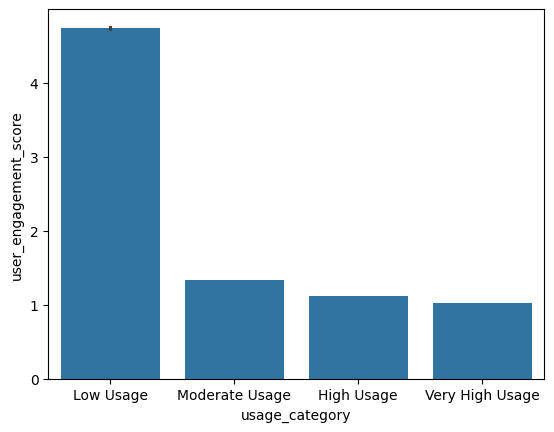

In [ ]:
# Create stress categories

df["stress_range"] = pd.cut(
    df["perceived_stress_score"],
    bins=[0, 2, 4, 6, 8, 10],
    labels=[
        "Very Low",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

sns.barplot(
    data=df,
    x="usage_category",
    y="user_engagement_score"
)

<Axes: xlabel='usage_category', ylabel='self_reported_happiness'>

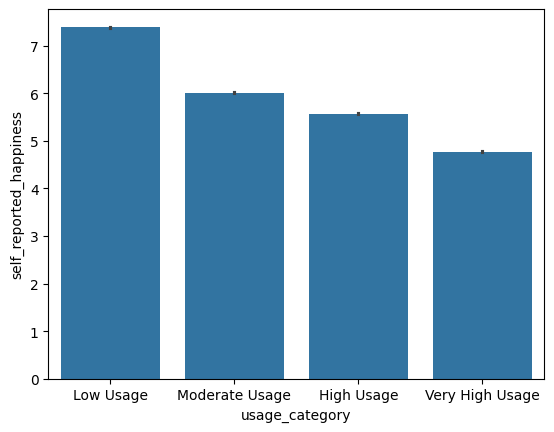

In [20]:
sns.barplot(
    data=df,
    x="usage_category",
    y="self_reported_happiness"
)

In [17]:
df[[
    "daily_active_minutes_instagram",
    "perceived_stress_score",
    "self_reported_happiness",
    "user_engagement_score",
    "sleep_hours_per_night"
]].corr(numeric_only=True)

,daily_active_minutes_instagram,perceived_stress_score,self_reported_happiness,user_engagement_score,sleep_hours_per_night
daily_active_minutes_instagram,1.000000,0.834515,-0.372172,-0.529977,-0.001529
perceived_stress_score,0.834515,1.000000,0.000783,-0.436399,-0.001969
self_reported_happiness,-0.372172,0.000783,1.000000,0.268017,-0.000032
user_engagement_score,-0.529977,-0.436399,0.268017,1.000000,0.000568
sleep_hours_per_night,-0.001529,-0.001969,-0.000032,0.000568,1.000000
